# PHASE 3
## Project Medical Cost
##### tala

## Import Libraries

In [152]:
import pandas as pd # work with data
import numpy as np # use calculatons
import seaborn as sns # use to draw graphs
import matplotlib.pyplot as plt # use ploting graphs

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## laod the enhanced file

In [153]:
df = pd.read_csv('/content/enhanced_data.csv') #read the database

In [154]:
print("\033[94m_______________________________________________First 5 rows_____________________________________________________\033[0m \n")
df.head() #show first 5 rows to make sure data read correctly

_______________________________________________First 5 rows_____________________________________________________ 



,age,sex,bmi,children,smoker,region,charges,bmi&child,fat,elderly,ChargesLog,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,0.00,0,530.100,9.734236,Young Adult
1,18,male,33.770,1,no,southeast,1725.55230,33.77,1,607.860,7.453882,child
2,28,male,33.000,3,no,southeast,4449.46200,11.00,1,924.000,8.400763,Young Adult
3,33,male,22.705,0,no,northwest,21984.47061,0.00,0,749.265,9.998137,Young Adult
4,32,male,28.880,0,no,northwest,3866.85520,0.00,0,924.160,8.260455,Young Adult


## Histograms / KDE

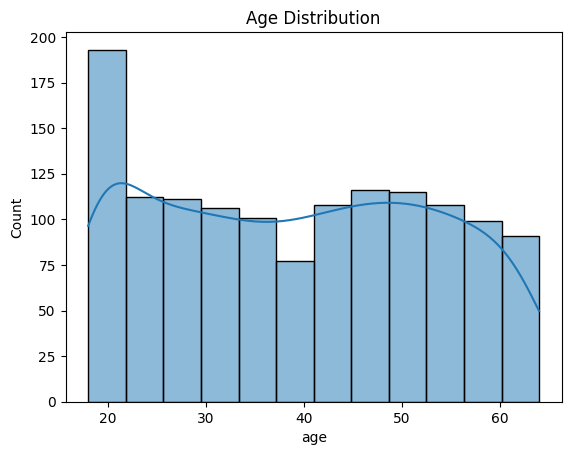

In [155]:
plt.figure() # for create plot
sns.histplot(df['age'], kde = True) # plot histogram of age , kde to show the font
plt.title('Age Distribution') # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
this figure explains Distribution ages , with Good representation of different age groups.Most individuals are concentrated in the middle age group,Without focusing on any particular age group, which makes the analysis balanced and reliable.


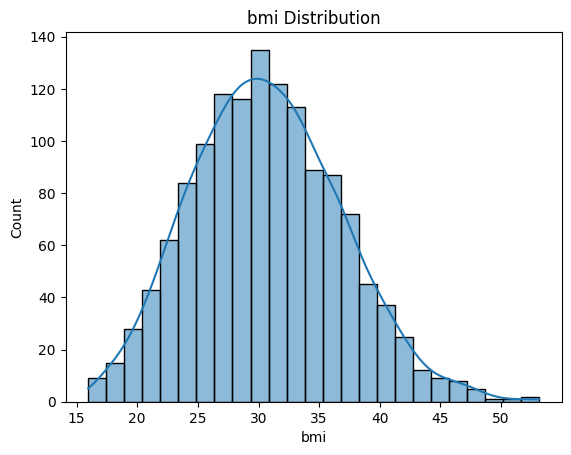

In [156]:
plt.figure() # for create plot
sns.histplot(df['bmi'], kde = True) # plot histogram of bmi , kde to show the font
plt.title('bmi Distribution') # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
The chart shows that the body mass index slightly leans to the right, with most individuals having average values, while there is a small segment with high values. These values may be classified by health insurance.

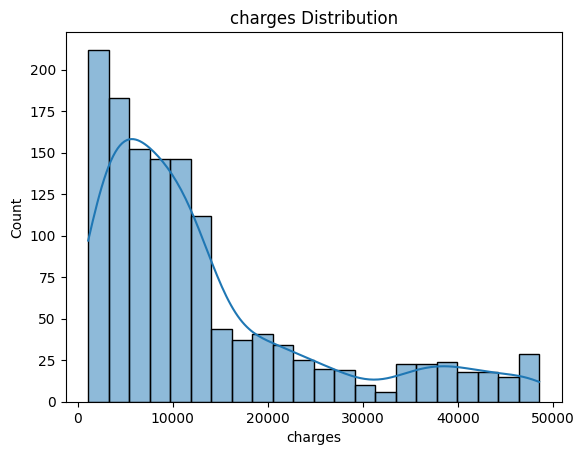

In [157]:
plt.figure() # for create plot
sns.histplot(df['charges'], kde = True) # plot histogram of charges , kde to show the font
plt.title('charges Distribution') # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
The costs show a right skew with a long tail, meaning that most have moderate costs while a few bear very high costs. This indicates that the costs are concentrated in a small segment, which is important for risk assessment and pricing strategies.

## Grouped boxplots

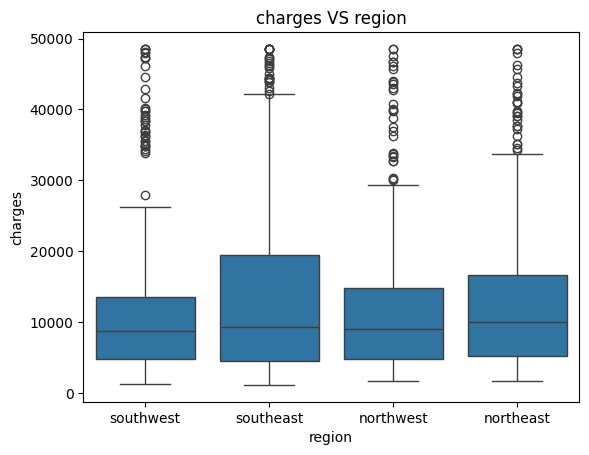

In [158]:
plt.figure() # for create plot
sns.boxplot(x = "region" , y = "charges" , data = df) # plot boxplot show the distribution for charges & region
plt.title('charges VS region') # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
The chart shows that the differences between regions in costs are not large, with average values being close. This indicates that the geographic region has a limited effect on costs in this data.

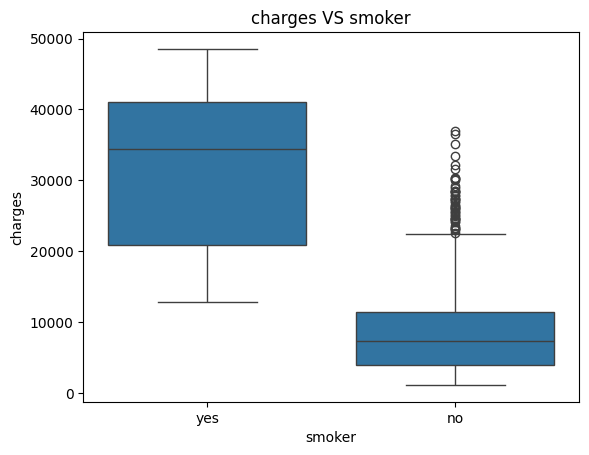

In [159]:
plt.figure() # for create plot
sns.boxplot(x = "smoker" , y = "charges" , data = df) # plot boxplot show the distribution for charges & smoker
plt.title('charges VS smoker') # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
The chart shows a clear difference between smokers and non-smokers. Smokers have significantly higher costs and greater variability in values, confirming that smoking is a major factor in increased health costs.

## Correlation heatmap

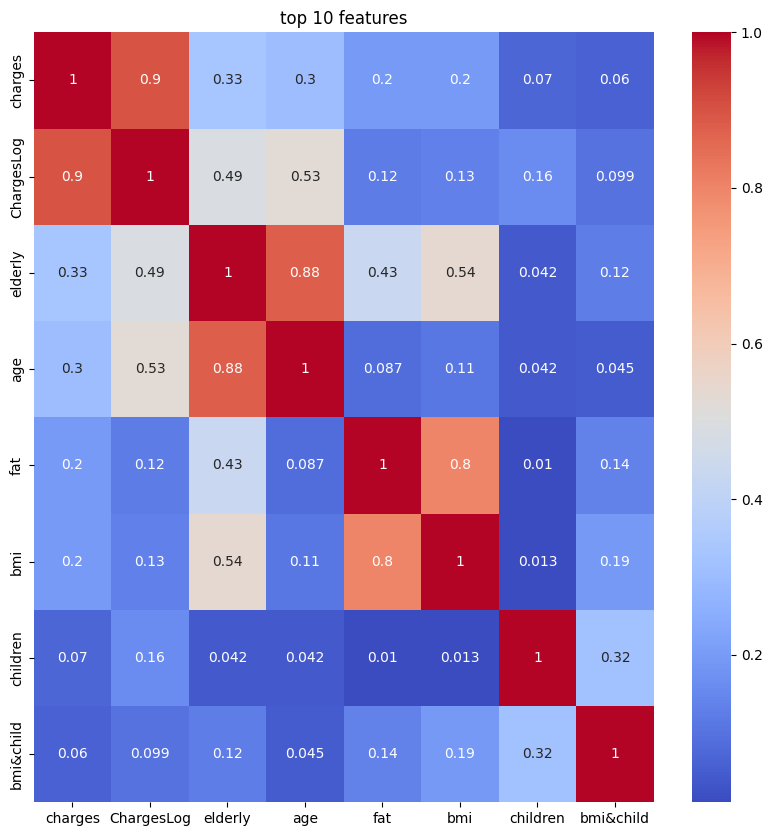

In [160]:
corr = df.corr(numeric_only=True) #corr matrix for numeric col only
top = corr["charges"].abs().sort_values(ascending=False).head(10).index # select top 10 features most corr with "charges"
plt.figure(figsize=(10, 10)) # for create plot , and select size of plot
sns.heatmap(df[top].corr(), annot=True, cmap = "coolwarm") # plot heatmap for corr between top 10 , annot=True show numerical corr value on plot
plt.title("top 10 features") # title of plot
plt.show() # to print the plot

## Write a 1-paragraph
The heatmap shows that costs are strongly associated with smoking, age, and BMI, while the other features have a weak effect. This helps in identifying the most important variables when building predictive models.



## Scatter plot

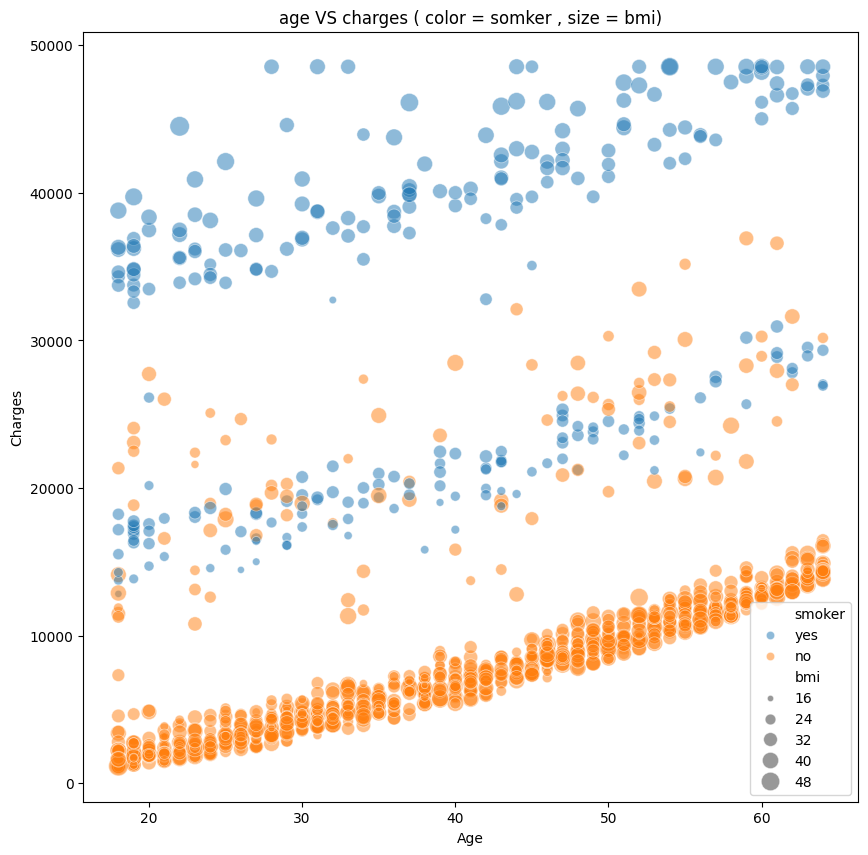

In [161]:
plt.figure(figsize=(10, 10)) # for create plot , and select size of plot
sns.scatterplot(
                x = "age", # set age in x axis
                y = "charges",  # set charges in y axis
                hue = "smoker", # color the points from smoker
                size = "bmi" , # set size of points from smoking
                sizes = (20,200) , # set size of points based on bmi
                data = df , # point sizes between 20 & 200
                alpha = 0.5 ) # make the points semi transparent
plt.title("age VS charges ( color = somker , size = bmi)") # title of plot
plt.xlabel("Age") # label x axis "age"
plt.ylabel("Charges") # label y axis "charges"
plt.show() # to print the plot

## Write a 1-paragraph
The chart shows a positive relationship between age and costs, with a clear distinction for smokers who bear higher costs. The size of the points related to BMI also indicates that individuals with a high index often have higher costs, reflecting the impact of several combined factors on expenses.

 ## Groupby summary

In [162]:
group = df.groupby("smoker")["charges"].mean() # group smoker & charges and calculate the mean
print(group) # show the mean

smoker
no      8440.660307
yes    31807.519571
Name: charges, dtype: float64


In [163]:
print("\033[94m -----Highest----- \033[0m") # Illustrative print of the outputs
group.max() # the highest groupay

 -----Highest----- 


31807.51957117518

In [164]:
print("\033[94m -----lowest-----\033[0m") # Illustrative print of the outputs
group.min() # the lowest groupay

 -----lowest-----


8440.660306508938

## Compute the mean and standard deviation

In [165]:
charges = df["charges"].values # convert charges to numpy array
mean = np.sum(charges) / len(charges) # compute mean manually
std = np.sqrt(np.sum((charges - mean) ** 2) / len(charges)) # Compute std manually
print("mean :" , mean) #show the mean
print("std :" , std) # show the std

mean : 13229.380903755422
std : 11937.109835237112


## Standardisation (Z-score)

In [166]:
x = df["bmi"].values # extract "bmi"numpy array
mean = np.mean(x) # compute mean of bmi
std = np.std(x) # compute std of bmi
z = (x - mean) / std # Z-score manually
print("Z-score:", z[:5]) # print first 5 standardized values

Z-score: [-0.45315959  0.50942165  0.3831546  -1.30505219 -0.29245608]


#### compare with StandardScaler

In [167]:
scaler = StandardScaler()  # Create a StandardScaler in Variable
compare = scaler.fit_transform(df[["bmi"]]) # Standardize the 'bmi' column using StandardScaler (convert to Z-scores)
print(compare[:5]) # show the first 5 standardized BMI values

[[-0.45315959]
 [ 0.50942165]
 [ 0.3831546 ]
 [-1.30505219]
 [-0.29245608]]


## Compute cosine similarity

In [168]:
high = df[df["charges"] == df["charges"].max()].iloc[0] # Get the row with the highest 'charges' value (first one)
low = df[df["charges"] == df["charges"].min()].iloc[0]# Get the row with the lowest 'charges' value (first one)

features = ["age","bmi","children"] # Select numerical features

v1 = high[features].values
v2 = low[features].values
# Extract feature values as NumPy arrays
similarity = np.dot(v1,v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)) # Compute between the highest and lowest
print("Cosine similarity:", similarity)

Cosine similarity: 0.9997552244990708


## Estimate a probability

In [169]:
threshold = 20000 # select threshold to classify high charges
high = df[df["charges"] > threshold] # filter where charges exceed the threshold
prob = len(high) / len(df) # Compute the fraction of records above the threshold
print("Probability:", prob) # show Probabilities

Probability: 0.20418848167539266


In [170]:
df.to_csv("final_data_insurance.csv", index=False) # to save dataset after cleaning to import in another